## Interpretability
How well can children learning with a certain algorithm understnd eachother?

In [1]:
# imports
from november_lib import Player, NaiveBayesPlayer, LinearFunctionPlayer, \
    SigmoidPlayer, MLPPlayer, LRPlayer, StrictPlayer, predict_interpretability
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# setup fake board
fake_policy = np.zeros((1000,), dtype=int)
fake_policy[:475] = 1
fake_policy[525:] = 2

In [2]:
# Constants
n_children = 100    # number of children to teach - O(n_children^2)
states = 1000
signals = 2
samples = 200
threshold = 0.8

info = (signals, states, samples, threshold)

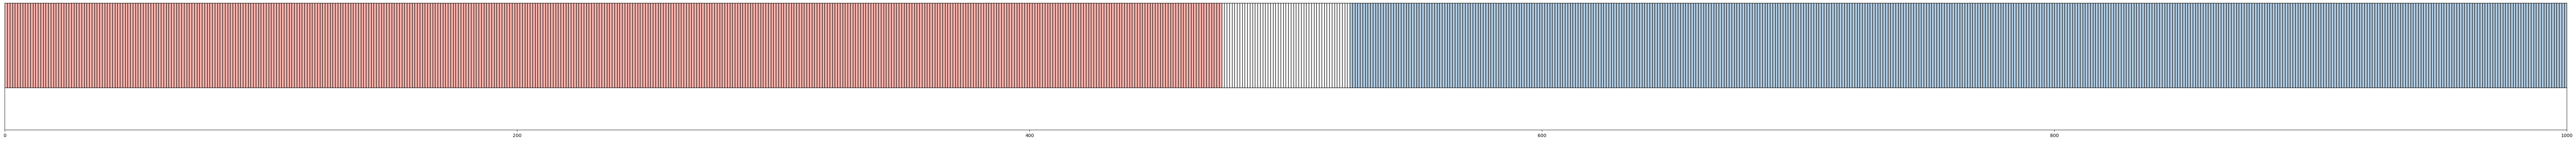

In [3]:
global_parent = Player(policy=fake_policy, n_signals=signals, n_states=states)
example_set = [global_parent.poll(samples) for _ in range(n_children)]
plt.figure(figsize=(100, 5))
ax = plt.gca()
ax = global_parent.plot_strategy(ax)
plt.show()

`predict_interpretability()` is passed a policy and an algorithm type along with some basic game parameters, set above. It teaches `n_children` unique "children" which play one round of SG3, where the ith child is trained on the ith set of examples from the global parent. In other words, `n_children` random example sets are taken from the global parent, then passed to train n children, reusing the same set of sets of examples for each algortim. Then, each unique pair of children is scored for utility. The average of these utility scores, or interpretability, is then returned.

In pseudocode:
```
parent = Player(policy)
poll parent n times -> global_examples
for i in range(n):
    child = new Player()
    child.learn(global_examples[i], threshold)
    child -> child_list

for i in range(n_children)
    for j in range(i+1, n_children):
        score = child_list[i].utility(child_list[j])
        score -> scores

return sum(scores) / len(scores)
```

### Basic player
Implements KNN.

Average interpretability: 0.9887224242424172
Greatest disagreement: 0.968


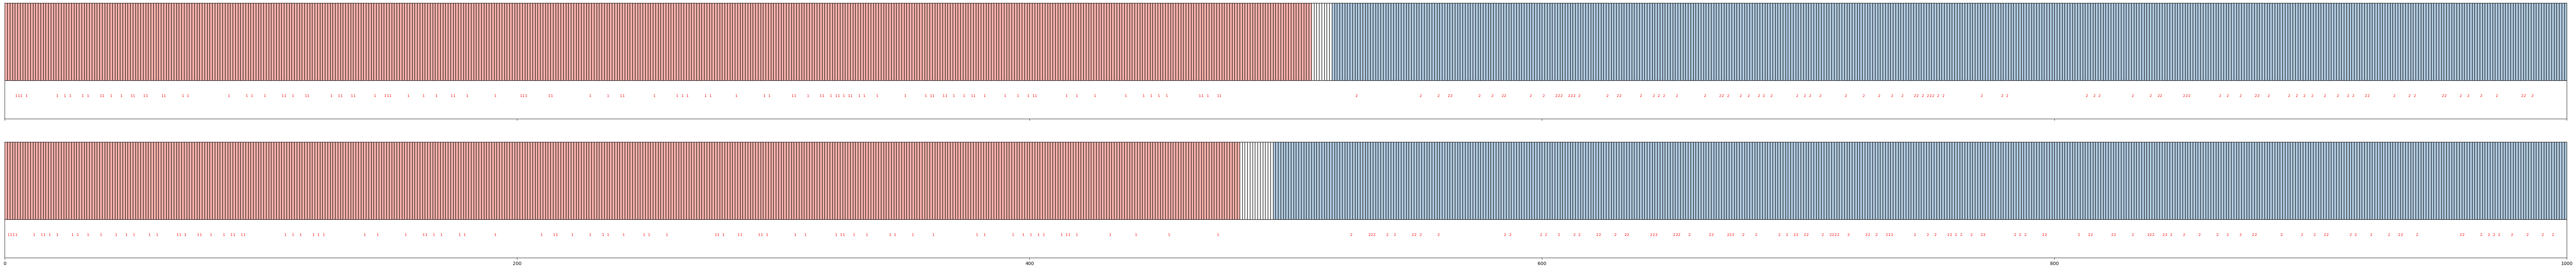

In [4]:
avg, lo_score, lo_pair = predict_interpretability(example_set, Player, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Strict Player
No generalization to unseen states.

Average interpretability: 0.9673772727272782
Greatest disagreement: 0.937


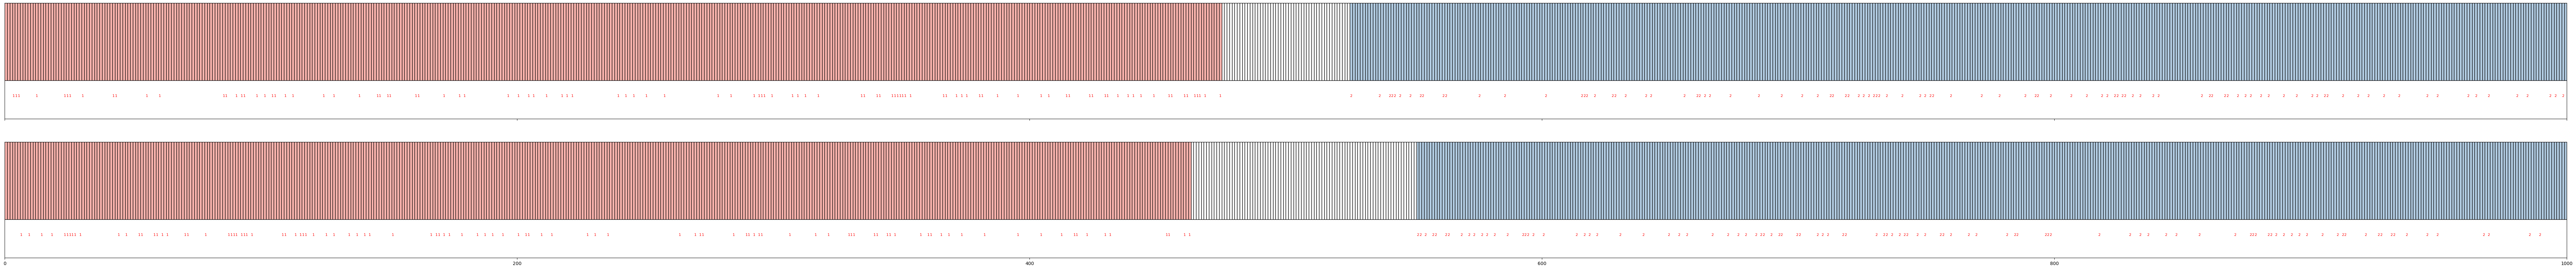

In [5]:
avg, lo_score, lo_pair = predict_interpretability(example_set, StrictPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Linear Function Player
Draws a line between `(1(g)_max_, 1)` and `(2(g)_min_, 0)`, with a mirror between `(1(g)_max_, 0)` and `(2(g)_min_, 1)`, to assess signal confidence.

Average interpretability: 0.9791804040404032
Greatest disagreement: 0.96


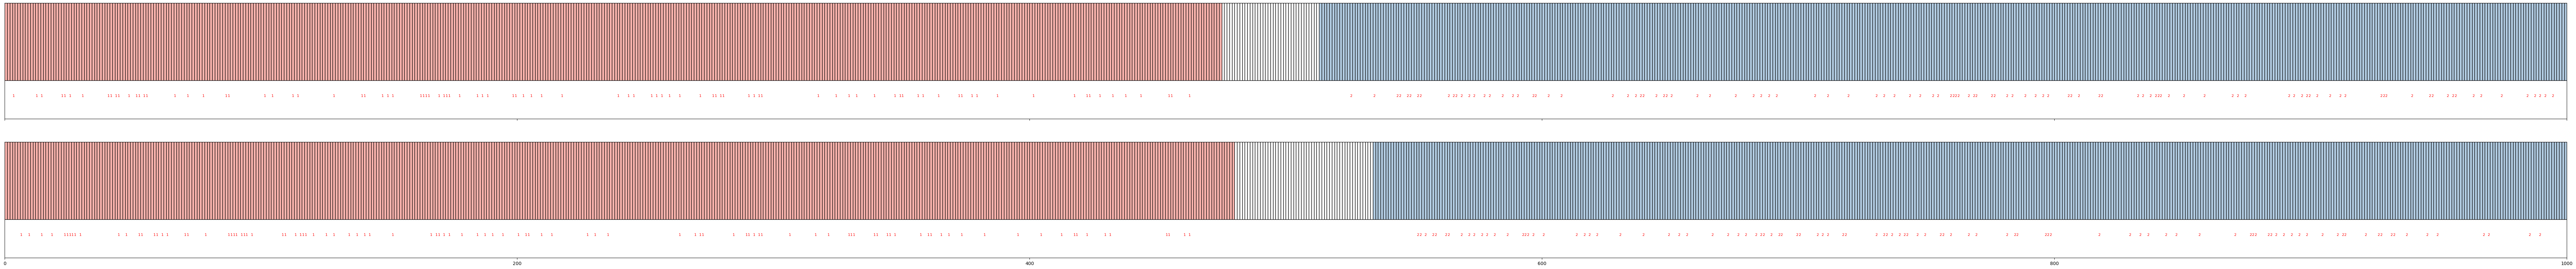

In [6]:
avg, lo_score, lo_pair = predict_interpretability(example_set, LinearFunctionPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Sigmoid Player
Draws a sigmoid between `(1(g)_max_, 1)` and `(2(g)_min_, 0)`, with a mirror between `(1(g)_max_, 0)` and `(2(g)_min_, 1)`, to assess signal confidence. Like the linear function, each sigmoid yeilds 0.5 at the halfway point between 1(g)_max_ and 2(g)_min_.

Average interpretability: 0.9868680808080805
Greatest disagreement: 0.9715


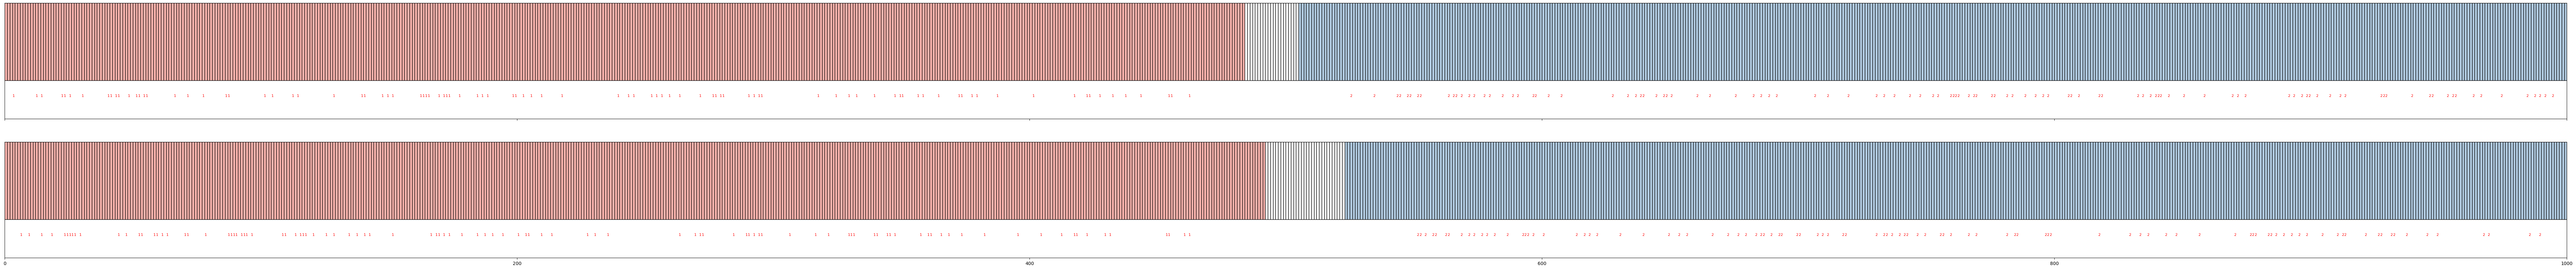

In [7]:
avg, lo_score, lo_pair = predict_interpretability(example_set, SigmoidPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Multi-layer Perceptron Player
Implements scikit-learn's `MLPClassifier` [citation needed] which assings a confidence score to each state in it's policy. Then, the threshold is applied to those scores. This approach is shared by the remaining classifiers implemented using the scikit-learn API. 



https://scikit-learn.org/1.6/about.html#citing-scikit-learn

Average interpretability: 0.969756868686864
Greatest disagreement: 0.9495


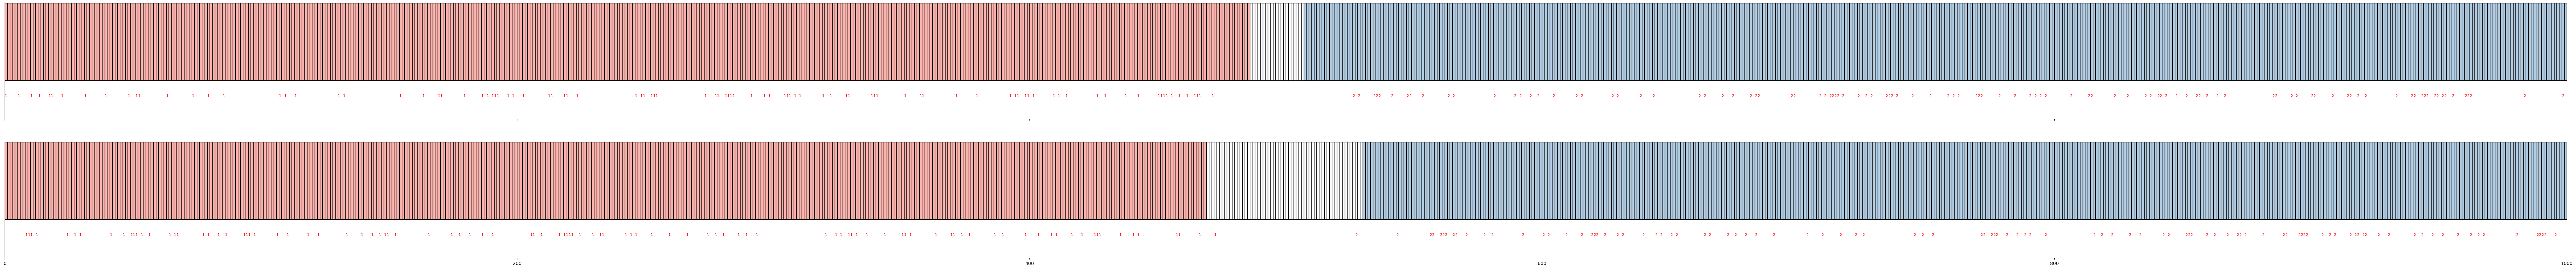

In [8]:
avg, lo_score, lo_pair = predict_interpretability(example_set, MLPPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Linear Regression Player
Implements scikit-learn's `LinearRegressionClassifier`.

Average interpretability: 0.9901484848484843
Greatest disagreement: 0.977


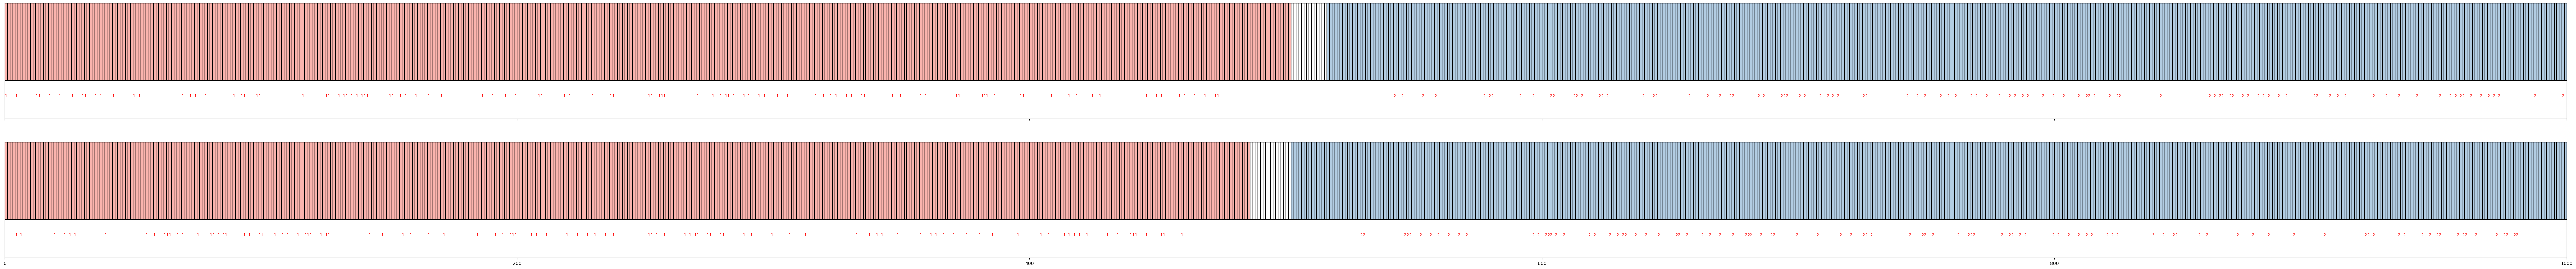

In [9]:
avg, lo_score, lo_pair = predict_interpretability(example_set, LRPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Naive Bayes Player
Implements scikit-learn's `GaussianNB` classifier.

Average interpretability: 0.9366443434343392
Greatest disagreement: 0.8975


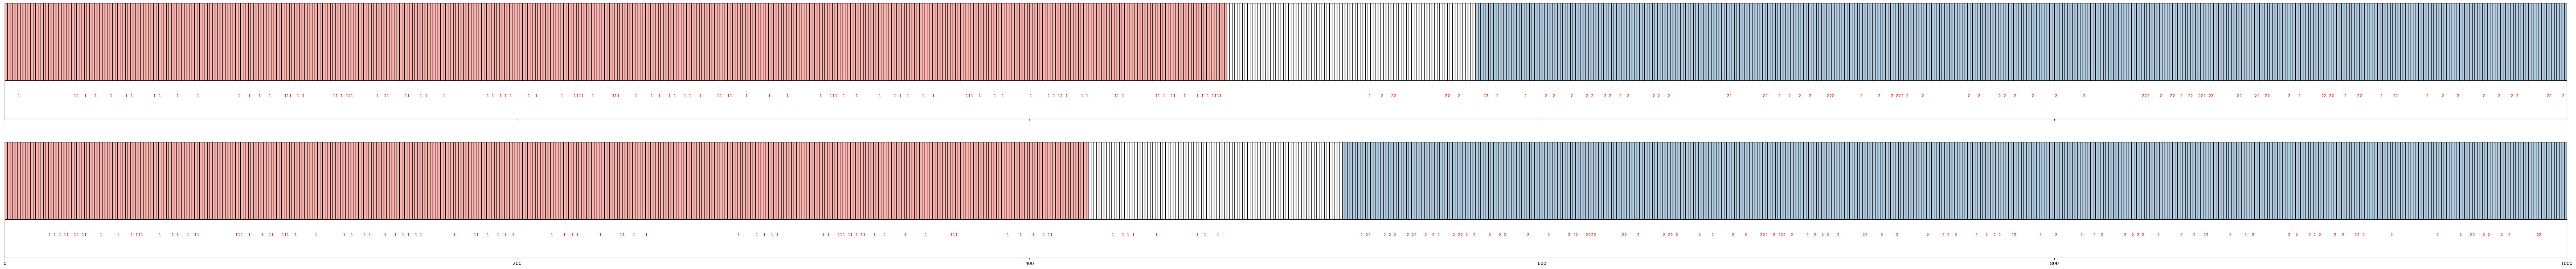

In [10]:
avg, lo_score, lo_pair = predict_interpretability(example_set, NaiveBayesPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()